In [1]:
# вычисление численных решений
# выбранной колебательной системы
# под действием внешней силы,
# приложенной к выбранной массе

# Ячейка № 1

# подключение библиотеки numpy
import numpy as np

# подключение метода solve_ivp
# из библиотеки scipy.integrate
from scipy.integrate import solve_ivp

# подключение библиотеки matplotlib
import matplotlib.pyplot as plt

In [2]:
# Ячейка № 2

# задание функции, возвращающей значения
# первых производных СДУ (9.27)
def Deriv(t, x):
    z = np.zeros(2 * N)
    z[0] = x[1]
    z[1] = (
        -Omega[0, 0] * x[0]
        - Omega[1, 0] * (x[0] - x[2])
        + Alpha_m[1, 0] * (x[0] - x[2]) ** 2
        - Alpha_m[0, 0] * x[0] ** 2
        + Beta_m[1, 0] * (x[0] - x[2]) ** 3
        - Beta_m[0, 0] * x[0] ** 3
    )
    if Nball == 0:
        z[1] = z[1] + FV(t)
    K = 2
    for i in range(N - 2):
        z[K] = x[K + 1]
        z[K + 1] = (
            -Omega[i + 1, i + 1] * (x[K] - x[K - 2])
            - Omega[i + 2, i + 1] * (x[K] - x[K + 2])
            + Alpha_m[i + 2, i + 1] * (x[K] - x[K + 2]) ** 2
            - Alpha_m[i + 1, i + 1] * (x[K] - x[K - 2]) ** 2
            + Beta_m[i + 2, i + 1] * (x[K] - x[K + 2]) ** 3
            - Beta_m[i + 1, i + 1] * (x[K] - x[K - 2]) ** 3
        )
        if (Nball > 0) & (Nball < N - 2):
            z[K + 1] = z[K + 1] + FV(t)
        K = K + 2
    z[2 * N - 2] = x[2 * N - 1]
    z[2 * N - 1] = (
        -Omega[N - 1, N - 1] * (x[2 * N - 2] - x[2 * N - 4])
        - Omega[N, N - 1] * x[2 * N - 2]
        + Alpha_m[N, N - 1] * x[2 * N - 2] ** 2
        - Alpha_m[N - 1, N - 1] * (x[2 * N - 2] - x[2 * N - 4]) ** 2
        + Beta_m[N, N - 1] * x[K - 2] ** 3
        - Beta_m[N - 1, N - 1] * (x[2 * N - 2] - x[2 * N - 4]) ** 3
    )
    if Nball == N - 1:
        z[2 * N - 1] = z[2 * N - 1] + FV(t)
    return z

In [3]:
# Ячейка № 3

# задание функции, возвращающей
# мгновенные значения внешней
# вынуждающей силы
def FV(t):
    return A * np.sin(OmegaFV * t)

In [ ]:
# Ячейка № 4

# задание числа масс
# колебательной системы
N = 5

# задание значений масс
# колебательной системы
m = np.ones(N)

# задание жесткостей пружин
# колебательной системы
k = np.ones(N + 1)

# вычисление матрицы Omega
Omega = np.zeros([N + 1, N])

for i in range(N + 1):
    for j in range(N):
        Omega[i, j] = k[i] / m[j]

# инициализация массива omega,
# используемого для хранения
# матрицы omega, вычисляемой
# в сооответствие с (9.8)
omega = np.zeros([N, N])

# вычисление вычисление значений
# элементов матрицы Omega
# в соответствии с (9.8)
for i in range(N):
    if i == 0:
        omega[0, 0] = Omega[0, 0] + Omega[1, 0]
        omega[0, 1] = -Omega[1, 0]
    if i > 0:
        if i < N - 1:
            omega[i, i - 1] = -Omega[i, i]
            omega[i, i] = Omega[i, i] + Omega[i + 1, i]
            omega[i, i + 1] = -Omega[i + 1, i]
        else:
            omega[i, i - 1] = -Omega[i, i]
            omega[i, i] = Omega[i, i] + Omega[i + 1, i]

# задание коэффициентов
# квадратичных составляющих нелинейностей
# пружин колебательной системы
# для задания нулевых значений
# коэффициентов квадратичных нелинейностей
# заменить в следующей строчке ones на zeros и наоборот
alpha = 0.2 * np.zeros(N + 1)

# инициализация массива Alpha_m,
# используемого для хранения отношений
# квадратических составляющих нелинейностей
# жесткостей пружин к массам тел
# колебательной системы
Alpha_m = np.zeros([N + 1, N])

# вычисление значений отношений
# коэффициентов квадратичных нелинейностей
# к массам грузов
for i in range(N + 1):
    for j in range(N):
        Alpha_m[i, j] = alpha[i] / m[j]

# задание коэффициентов
# кубических составляющих нелинейностей
# пружин колебательной системы
# для задания нулевых значений
# коэффициентов кубических нелинейностей
# заменить в следующей строчке ones на zeros и наоборот
beta = 0.1 * np.zeros(N + 1)

Beta_m = np.zeros([N + 1, N])

# вычисление значений отношений
# коэффициентов кубических нелинейностей
# к массам грузов
for i in range(N + 1):
    for j in range(N):
        Beta_m[i, j] = beta[i] / m[j]

# вычисление собственных чисел и
# собственных векторов матрицы Omеga,
# элементы которой вычисляются
# в соответствие с (9.4)
Teta, Sigma = np.linalg.eig(omega)

# вычисление матрицы, обратной
# матрице omega
S = np.linalg.inv(omega)

R0 = np.zeros(N)
V0 = np.zeros(N)

# инициализация и заполнение массива Nu,
# используемого для хранения начальных условий
# в формате, используемым в функции Solv_inv
Nu = np.zeros(2 * N)
for i in range(N):
    Nu[2 * i] = R0[i]
    Nu[2 * i + 1] = V0[i]

# задание шага
# координатной сетки
Tfin = 1500
Np = 2**21
dt = Tfin / Np

# задание параметров вынуждающей силы

# задание циклической частоты
# вынуждающей силы, приложенной
# к одной из масс колебательной системы,
# собственной циклической частоте
# выбранной моды нормальных колебаний
# номер моды Nn (0,1,2,4)
Nn = 4
OmegaFV = np.sqrt(Teta[Nn])

# задание амплитуды
# вынуждающей силы
A = 0.1

# задание номера массы, к которой
# приложена внешняя вынуждающая сила
Nball = 0

# вычисление численного решения СДУ (9.27)
Solv = solve_ivp(Deriv, [0, Tfin], Nu, method="RK45", t_eval=np.linspace(0, Tfin, Np))


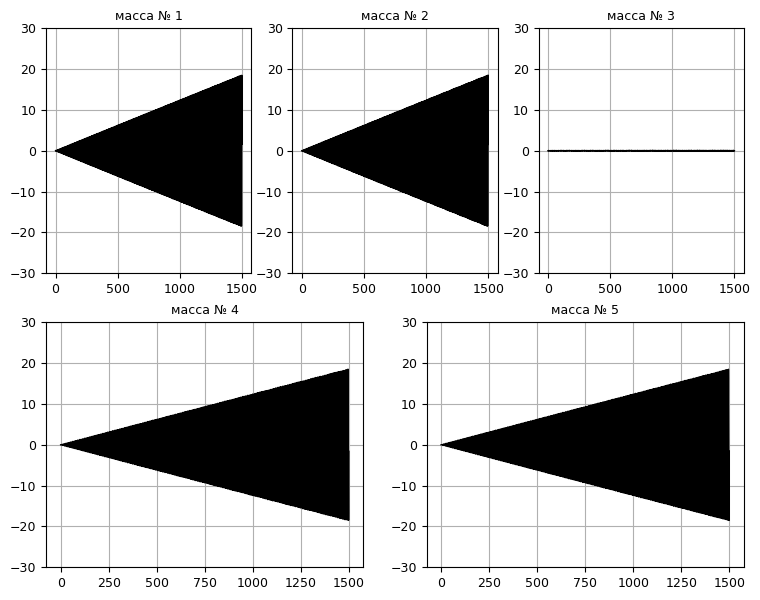

In [5]:
# Ячейка № 5

# визуализация зависимостей
# отклонений масс колебательной системы
# от времени

# визуализация зависимостей
# смещений масс колебательной системы
# от их положений равновесия от времени
fig = plt.figure(figsize=(9, 7))

Ymin = -30
Ymax = 30

ax = fig.add_subplot(2, 2, 3)
ax.grid(True)
ax.set_ylim(Ymin, Ymax)
ax.set_title("масса № 4", fontsize=9)
ax.tick_params(labelsize=9)
ax.plot(Solv.t[:], Solv.y[6, :], "-k", lw=1)

ax = fig.add_subplot(2, 2, 4)
ax.grid(True)
ax.set_ylim(Ymin, Ymax)
ax.set_title("масса № 5", fontsize=9)
ax.tick_params(labelsize=9)
ax.plot(Solv.t[:], Solv.y[8, :], "-k", lw=1)

ax = fig.add_subplot(2, 3, 1)
ax.grid(True)
ax.set_ylim(Ymin, Ymax)
ax.set_title("масса № 1", fontsize=9)
ax.tick_params(labelsize=9)
ax.plot(Solv.t[:], Solv.y[0, :], "-k", lw=1)

ax = fig.add_subplot(2, 3, 2)
ax.grid(True)
ax.set_ylim(Ymin, Ymax)
ax.set_title("масса № 2", fontsize=9)
ax.tick_params(labelsize=9)
ax.plot(Solv.t[:], Solv.y[2, :], "-k", lw=1)

ax = fig.add_subplot(2, 3, 3)
ax.grid(True)
ax.set_ylim(Ymin, Ymax)
ax.set_title("масса № 3", fontsize=9)
ax.tick_params(labelsize=9)
ax.plot(Solv.t[:], Solv.y[4, :], "-k", lw=1)

plt.show()

In [6]:
print(np.sqrt(Teta[:]))

[1.93185165 1.73205081 1.41421356 0.51763809 1.        ]


In [ ]:
# Ячейка № 6

# вычисление мгновенных зависимостей
# координат мод нормальных колебаний
# от времени

# вычисление собственных чисел и
# собственных векторов матрицы omеga
Teta, Sigma = np.linalg.eig(omega)

# инициализация массива Teta_M,
# используемого для создания
# диагональной матрицы, в которой
# на главной диагонали размещаются с
# соответствующие собственные числа матрицы B
Teta_M = np.zeros([N, N])

# размещение на главной диагонали матрицы Teta_M
# сответствующего собственных чисел матрицы B
for i in range(N):
    Teta_M[i, i] = np.sqrt(Teta[i])

# вычисление матрицы,
# обратной матрице Sigma
Sx = np.linalg.inv(Sigma)

# перемещение численного
# решения СДУ (9.30) из массива размерностью N x Np
# в массив размерностью Np x N
Y1 = Solv.y.T

# инициализация массива X2,
# используемого для хранения мгновенных значений
# смещений от положения равновесия
# масс колебательной системы
X2 = np.zeros([Np, N])

# инициализация массива V2,
# используемого для хранения мгновенных значений
# скоростей масс колебательной системы
V2 = np.zeros([Np, N])

# перемещение значений координат и
# скоростей масс колебательной системы
# в массивы X2 и V2, соответственно
for i in range(N):
    X2[:, i] = Y1[:, 2 * i]
    V2[:, i] = Y1[:, 2 * i + 1]

# инициализация массива Xn,
# используемого для хранения
# координат мгновенных значений
# нормальных колебаний
# масс колебательной системы
Xn = np.zeros([Np, N])

# инициализация массива Vn,
# используемого для хранения мгновенных значений
# скоростей нормальных колебаний
Vn = np.zeros([Np, N])

# вычисление мгновенных значений
# координат и скоростей колебательной системы
# в соответствие с (9.31)
for i in range(Np):
    Xn[i, :] = np.dot(Sx, X2[i, :])
    Vn[i, :] = np.dot(Sx, V2[i, :])


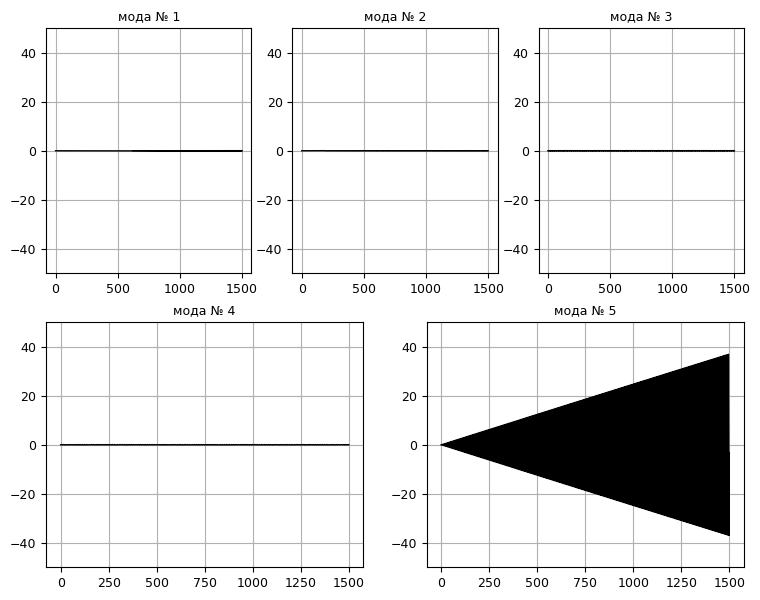

In [8]:
# Ячейка № 7

# визуализация зависимостей
# мод нормальных колебаний
# от времени

fig = plt.figure(figsize=(9, 7))

Ymin = -50
Ymax = 50

ax = fig.add_subplot(2, 2, 3)
ax.grid(True)
ax.set_ylim(Ymin, Ymax)
ax.set_title("мода № 4", fontsize=9)
ax.tick_params(labelsize=9)
ax.plot(Solv.t[:], Xn[:, 3], "-k", lw=1)

ax = fig.add_subplot(2, 2, 4)
ax.grid(True)
ax.set_ylim(Ymin, Ymax)
ax.set_title("мода № 5", fontsize=9)
ax.tick_params(labelsize=9)
ax.plot(Solv.t[:], Xn[:, 4], "-k", lw=1)

ax = fig.add_subplot(2, 3, 1)
ax.grid(True)
ax.set_ylim(Ymin, Ymax)
ax.set_title("мода № 1", fontsize=9)
ax.tick_params(labelsize=9)
ax.plot(Solv.t[:], Xn[:, 0], "-k", lw=1)

ax = fig.add_subplot(2, 3, 2)
ax.grid(True)
ax.set_ylim(Ymin, Ymax)
ax.set_title("мода № 2", fontsize=9)
ax.tick_params(labelsize=9)
ax.plot(Solv.t[:], Xn[:, 1], "-k", lw=1)

ax = fig.add_subplot(2, 3, 3)
ax.grid(True)
ax.set_ylim(Ymin, Ymax)
ax.set_title("мода № 3", fontsize=9)
ax.tick_params(labelsize=9)
ax.plot(Solv.t[:], Xn[:, 2], "-k", lw=1)

plt.show()

In [9]:
# Ячейка № 8

# вычисление матрицы
# в соответствие с (9.48)

# задание вектора внешней силы
F = np.array([1, 0, 0, 0, 0])

# создание на основе массива m
# диагональную матрицу
M = np.diag(m)

# определение числа
# элементов вектора F
ML = len(F)

# вычисление матрицы R
# в соответствие с (9.48)
H = np.zeros(ML)
R = np.zeros([ML, ML])

for i in range(ML):
    H[i] = np.dot(F, Sigma.T[:, i]) / np.dot(np.dot(Sigma.T[:, i], M), Sigma.T[:, i])

for j in range(ML):
    for i in range(ML):
        R[i, j] = H[i] * Sigma.T[j, i]

print(np.round(S * 10**3) / 10**3)

[[0.833 0.667 0.5   0.333 0.167]
 [0.667 1.333 1.    0.667 0.333]
 [0.5   1.    1.5   1.    0.5  ]
 [0.333 0.667 1.    1.333 0.667]
 [0.167 0.333 0.5   0.667 0.833]]
